In [1]:
%load_ext autoreload
%autoreload 2

save_plot = True


In [2]:
import sys
sys.path.append('..')
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from results_analysis_helper import *
import json
import seaborn as sns

pd.set_option('display.max_rows', 100)

# Tell Matplotlib to export text as text, not paths (editable in Illustrator)
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
gene_perf = pd.read_parquet(f"/cwork/hl489/Pertb_benchmark/DataSet2/gene_perf_large_detail.parquet")

In [5]:
# Get perturbations present in every dataset
# datasets = gene_perf['dataset'].unique()
# common_perts = gene_perf.groupby('perturbation')['dataset'].nunique()
# common_perts = common_perts[common_perts == len(datasets)].index

# gene_2 = gene_2[gene_2['perturbation'].isin(common_perts)]
# gene_perf = gene_perf[~gene_perf.dataset.isin(['K562', 'HEK293T', 'HCT116'])]
# gene_perf = pd.concat([gene_perf, gene_2])

In [6]:
# gene_perf.groupby('dataset')['perturbation'].nunique()


In [7]:
# new_metrics = compute_new_corr_metrics(
#     gene_perf,
#     deg=[1000, 2000, 5000, 10000],
#     sign_tau=0.0,
#     updown_tau=0.0,
#     de_frac=0.1,
#     topk_values=(100,),
    
# )
# new_metrics.to_parquet("new_metrics_large.parquet",index=False)
new_metrics = pd.read_parquet("new_metrics_large.parquet")
new_metrics_small = pd.read_parquet("new_metrics.parquet")
new_metrics_inter = new_metrics[new_metrics.perturb.isin(new_metrics_small.perturb.tolist())]

In [8]:
new_metrics.perturb.nunique()

2278

In [9]:
# Check if any perturbation appears in multiple splits within the same dataset
dups = new_metrics.groupby(['DataSet', 'perturb', 'metric', 'DEG'])['split'].nunique()
print(dups[dups > 1])


Series([], Name: split, dtype: int64)


Cell lines: ['HCT_large', 'HEK_large', 'K562_large', 'hepg2_large', 'jurkat_large', 'rpe1_large']
Common perturbations: 2269
Method=trainMean, Metric=spearman_distance_delta, DEG=2000
Cell lines: ['HCT_large', 'HEK_large', 'K562_large', 'hepg2_large', 'jurkat_large', 'rpe1_large']
Lower = better | n=2269 common perturbations

TOP 10 BEST PREDICTED (lowest spearman_distance_delta)
DataSet  HCT_large  HEK_large  K562_large  hepg2_large  jurkat_large  rpe1_large  mean_perf
perturb                                                                                    
RPL12       0.2494     0.3340      0.3782       0.0781        0.2559      0.0846     0.2300
UTP15       0.2326     0.3537      0.4185       0.1662        0.1708      0.0956     0.2396
MED21       0.3033     0.2556      0.2974       0.1837        0.2223      0.1830     0.2409
EXOSC9      0.1588     0.3622      0.3663       0.2705        0.2235      0.1090     0.2484
WDR75       0.1893     0.2943      0.5356       0.1343        0.2

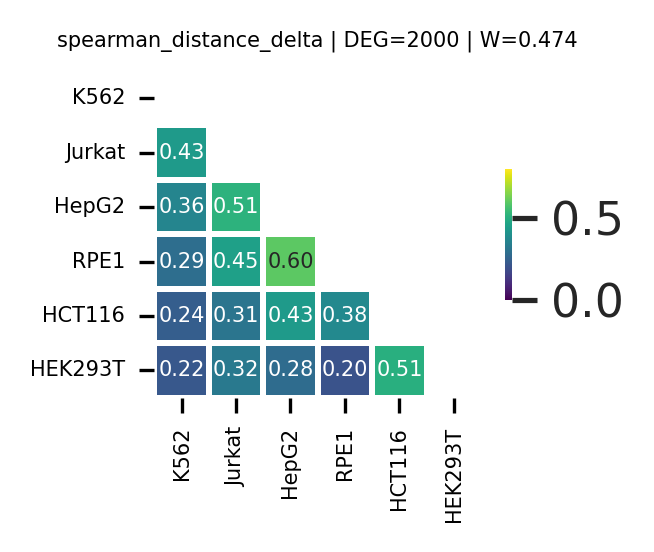

In [10]:
from scipy.stats import spearmanr
import itertools

cell_lines_order = ['K562', 'Jurkat', 'HepG2', 'RPE1', 'HCT116', 'HEK293T']
rename_map = {'hepg2': 'HepG2', 'jurkat': 'Jurkat', 'rpe1': 'RPE1',
              'K562_large': 'K562', 'jurkat_large': 'Jurkat', 'hepg2_large': 'HepG2',
              'rpe1_large': 'RPE1', 'HCT_large': 'HCT116', 'HEK_large': 'HEK293T'}

N = 1
new_metrics_filtered = new_metrics[new_metrics['Nstimulated'] >= N]

for metric in ['spearman_distance_delta']:
    pivot = perturbation_analysis(
        new_metrics_filtered, method="trainMean", metric=metric, deg=2000,
        top_n=10, agg_func='mean', verbose=True
    )
    pivot = pivot.rename(columns=rename_map)
    mat = pivot[cell_lines_order].dropna()

    # Build correlation matrix
    rho_mat = pd.DataFrame(1.0, index=cell_lines_order, columns=cell_lines_order)
    for a, b in itertools.combinations(cell_lines_order, 2):
        rho, _ = spearmanr(mat[a], mat[b])
        rho_mat.loc[a, b] = rho
        rho_mat.loc[b, a] = rho

    # Kendall's W
    ranks = mat[cell_lines_order].rank(axis=0)
    n = len(ranks)
    k = len(cell_lines_order)
    rank_sums = ranks.sum(axis=1)
    S = ((rank_sums - rank_sums.mean()) ** 2).sum()
    W = 12 * S / (k**2 * (n**3 - n))

    # Plot
    mask = np.triu(np.ones_like(rho_mat, dtype=bool))
    fig, ax = plt.subplots(figsize=(2.5, 2), dpi=300)
    sns.set_theme(style="white")
    sns.heatmap(rho_mat, annot=True, fmt='.2f', cmap='viridis',
                mask=mask, vmin=0, vmax=0.8, square=True,
                annot_kws={'fontsize': 5}, ax=ax,
                linewidths=1, linecolor='white',
                cbar_kws={'shrink': 0.4})
    ax.set_title(f'{metric} | DEG=2000 | W={W:.3f}', fontsize=5)
    ax.tick_params(labelsize=5)
    plt.tight_layout()
    plt.show()


In [9]:
# # Load split files
# splits = {}
# for s in range(5):
#     with open(f'/cwork/hl489/perturbBench/split{s}.json') as f:
#         splits[s] = json.load(f)

# psi_all_deg = []
# for deg in [1000, 2000, 5000]:
#     gp_tm = gene_perf[(gene_perf['method'] == 'trainMean') & (gene_perf['deg_rank'] <= deg)].copy()

#     rows = []
#     for split_idx in range(5):
#         train_perts = set(splits[split_idx]['train'])

#         gp_test = gp_tm[(gp_tm['split'] == split_idx)].copy()

#         other_splits = gp_tm[gp_tm['split'] != split_idx]
#         train_data = other_splits[other_splits['perturbation'].isin(train_perts)]

#         gene_avg = (train_data
#             .groupby(['dataset', 'gene'])['mean_true_delta']
#             .mean()
#             .rename('avg_gene_delta')
#         )

#         gp_test = gp_test.merge(gene_avg, on=['dataset', 'gene'], how='left')
#         gp_test['residual'] = gp_test['mean_true_delta'] - gp_test['avg_gene_delta']
#         rows.append(gp_test)

#     gp_all = pd.concat(rows, ignore_index=True)

#     psi_deg = (gp_all
#         .groupby(['dataset', 'perturbation'])
#         .apply(lambda g: g['residual'].var() / g['mean_true_delta'].var() if g['mean_true_delta'].var() > 0 else np.nan,
#                include_groups=False)
#         .rename('PSI')
#         .reset_index()
#     )
#     psi_deg['DEG'] = deg
#     psi_all_deg.append(psi_deg)
#     print(f"DEG={deg}: {len(psi_deg)} entries, {psi_deg['PSI'].notna().sum()} non-null")

# psi_all_deg = pd.concat(psi_all_deg, ignore_index=True)

# # Keep DEG=2000 as the default psi for the heatmap
# psi = psi_all_deg[psi_all_deg['DEG'] == 2000].drop(columns='DEG').reset_index(drop=True)

In [10]:
# n_celllines = psi.groupby('perturbation')['dataset'].nunique()
# perts_all6 = n_celllines[n_celllines == 6].index

# global_psi_simple = psi[psi['perturbation'].isin(perts_all6)].groupby('perturbation')['PSI'].mean().reset_index()
# global_psi_simple.columns = ['perturbation', 'global_PSI']

In [11]:
# # =========================================================
# # Random-effects meta-analysis for global PSI
# # =========================================================

# def random_effects_pool(log_vals, se_vals):
#     """DerSimonian-Laird random-effects pooling of log(PSI)."""
#     y = np.asarray(log_vals, dtype=float)
#     se = np.asarray(se_vals, dtype=float)

#     m = np.isfinite(y) & np.isfinite(se) & (se > 0)
#     y, se = y[m], se[m]
#     k = len(y)
#     if k == 0:
#         return None

#     v = se**2
#     if k == 1:
#         return {'mu_log': y[0], 'se_mu_log': se[0], 'tau2': 0.0,
#                 'I2_percent': np.nan, 'k_used': 1}

#     w = 1.0 / v
#     mu_fe = np.sum(w * y) / np.sum(w)
#     Q = np.sum(w * (y - mu_fe)**2)
#     C = np.sum(w) - np.sum(w**2) / np.sum(w)
#     tau2 = max(0.0, (Q - (k - 1)) / C) if C > 0 else 0.0

#     w_re = 1.0 / (v + tau2)
#     mu = np.sum(w_re * y) / np.sum(w_re)
#     se_mu = np.sqrt(1.0 / np.sum(w_re))
#     I2 = max(0.0, (Q - (k - 1)) / Q) * 100 if Q > 0 else 0.0

#     return {'mu_log': mu, 'se_mu_log': se_mu, 'tau2': tau2,
#             'I2_percent': I2, 'k_used': k}


# def compute_psi_with_bootstrap(gene_perf, splits, max_deg=2000,
#                                 n_boot=500, random_state=0, min_boot_ok=30):
#     """Per-dataset/per-perturbation PSI with bootstrap SE (split-aware, vectorized)."""
#     rng = np.random.default_rng(random_state)
#     rows = []

#     for ds in gene_perf['dataset'].dropna().unique():
#         gp_ds = gene_perf[
#             (gene_perf['dataset'] == ds) &
#             (gene_perf['method'] == 'trainMean') &
#             (gene_perf['deg_rank'] <= max_deg)
#         ]

#         for split_idx in range(5):
#             train_perts = set(splits[split_idx]['train'])
#             gp_split = gp_ds[gp_ds['split'] == split_idx]

#             test_perts = gp_split['perturbation'].unique()

#             other = gp_ds[gp_ds['split'] != split_idx]
#             train_data = other[other['perturbation'].isin(train_perts)]
#             gene_avg = train_data.groupby('gene')['mean_true_delta'].mean()

#             # Group once to avoid repeated filtering
#             for pert, sub in gp_split.groupby('perturbation'):
#                 sub = sub[sub['gene'].isin(gene_avg.index)]
#                 if len(sub) < 3:
#                     continue

#                 x = sub['mean_true_delta'].to_numpy(dtype=float)
#                 g = gene_avg.loc[sub['gene'].values].to_numpy(dtype=float)

#                 total_var = np.var(x, ddof=1)
#                 if not np.isfinite(total_var) or total_var <= 0:
#                     rows.append({'dataset': ds, 'split': split_idx,
#                                  'perturbation': pert, 'PSI': np.nan,
#                                  'log_PSI': np.nan, 'se_log_PSI': np.nan,
#                                  'n_genes': len(x), 'n_boot_ok': 0})
#                     continue

#                 resid_var = np.var(x - g, ddof=1)
#                 psi_val = resid_var / total_var
#                 log_psi = np.log(psi_val) if np.isfinite(psi_val) and psi_val > 0 else np.nan

#                 # Vectorized bootstrap SE for log(PSI)
#                 n = len(x)
#                 idx_all = rng.integers(0, n, size=(n_boot, n))
#                 xb_all = x[idx_all]
#                 gb_all = g[idx_all]
#                 vxb_all = np.var(xb_all, axis=1, ddof=1)
#                 resid_all = np.var(xb_all - gb_all, axis=1, ddof=1)
#                 good = np.isfinite(vxb_all) & (vxb_all > 0)
#                 sb_all = np.where(good, resid_all / vxb_all, np.nan)
#                 good2 = np.isfinite(sb_all) & (sb_all > 0)
#                 boot_logs = np.log(sb_all[good2])

#                 se_log = np.std(boot_logs, ddof=1) if len(boot_logs) >= min_boot_ok else np.nan

#                 rows.append({'dataset': ds, 'split': split_idx,
#                              'perturbation': pert, 'PSI': psi_val,
#                              'log_PSI': log_psi, 'se_log_PSI': se_log,
#                              'n_genes': n, 'n_boot_ok': len(boot_logs)})

#     return pd.DataFrame(rows)


# def compute_global_psi(spec_df):
#     """Random-effects pooling across datasets (and splits) per perturbation."""
#     ds_level = (spec_df.dropna(subset=['log_PSI', 'se_log_PSI'])
#         .groupby(['dataset', 'perturbation'])
#         .agg(log_PSI=('log_PSI', 'mean'),
#              se_log_PSI=('se_log_PSI', lambda x: np.sqrt((x**2).mean())),
#              n_splits=('split', 'count'))
#         .reset_index()
#     )

#     out = []
#     for pert, g in ds_level.groupby('perturbation'):
#         pooled = random_effects_pool(g['log_PSI'], g['se_log_PSI'])
#         if pooled is None:
#             continue
#         mu = pooled['mu_log']
#         se_mu = pooled['se_mu_log']
#         out.append({
#             'perturbation': pert,
#             'global_PSI': np.exp(mu),
#             'ci_low_95': np.exp(mu - 1.96 * se_mu),
#             'ci_high_95': np.exp(mu + 1.96 * se_mu),
#             'k_celltypes': pooled['k_used'],
#             'tau2': pooled['tau2'],
#             'I2_percent': pooled['I2_percent']
#         })

#     return pd.DataFrame(out).sort_values('global_PSI', ascending=False)


# # =========================================================
# # Run
# # =========================================================
# print("Computing per-dataset PSI with bootstrap SEs...")
# spec_boot = compute_psi_with_bootstrap(gene_perf, splits, max_deg=2000, n_boot=500)
# print(f"  {len(spec_boot)} (dataset, split, perturbation) entries")

# global_psi = compute_global_psi(spec_boot)
# print(f"  {len(global_psi)} perturbations with global PSI")
# print()
# print(global_psi.describe())
# print()
# print(global_psi.sort_values('global_PSI').head(20))

In [15]:
# psi_across_celllines = global_psi[global_psi.k_celltypes == 6].reset_index(drop=True)
# psi_across_celllines.to_parquet("PSI_rankings_large.parquet", index=False)
psi_across_celllines = pd.read_parquet("PSI_rankings_large.parquet")


In [16]:
psi_across_celllines[psi_across_celllines.perturbation.str.startswith("BRD")]

,perturbation,global_PSI,ci_low_95,ci_high_95,k_celltypes,tau2,I2_percent
364,BRD4,1.420670,0.977549,2.064656,6,0.215936,99.160498
567,BRD2,1.230410,0.919892,1.645745,6,0.130475,98.905415
1050,BRD8,0.929803,0.713936,1.210941,6,0.107594,98.936702


In [17]:
with open("../remap2022_unique_factors.txt") as f:
    remap_factors = [line.strip() for line in f]

with open("../remap2022_unique_factors.txt") as f:
    remap_all_factors = [line.strip() for line in f]

chipAtlas_factors = pd.read_csv("/cwork/hl489/perturbBench/chip_atlas_antigen_list.csv")
chipAtlas_factors = chipAtlas_factors[(chipAtlas_factors['Genome assembly'] == 'hg38') & 
((chipAtlas_factors['Antigen class'] == 'TFs and others') | (chipAtlas_factors['Antigen class'] == 'RNA polymerase'))]

BART = pd.read_parquet("/hpc/home/hl489/projects/ATAC_PREDICT_GENE_FUNCTION/data/TR_levels_gene/bart2_output_H1esc_closest5_unique_2.parquet")

all_possible = remap_all_factors + remap_factors + chipAtlas_factors["Antigen"].tolist() + BART.columns.tolist()
all_possible = set([x.upper() for x in all_possible if isinstance(x, str)] + ['non-targeting'])


In [18]:
PSI_METHOD = "random_effects"

In [19]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Load GO annotations
go_all_df = pd.read_parquet("/cwork/hl489/perturbBench/plotting_hammers/human_gene_go_annotations_large.parquet")

# Select PSI source based on config
if PSI_METHOD == "simple":
    psi_data = global_psi_simple.copy()
    print(f"Using SIMPLE mean PSI (n={len(psi_data)})")
else:
    psi_data = psi_across_celllines.copy()
    print(f"Using RANDOM-EFFECTS meta-analysis PSI (n={len(psi_data)})")

# Define quartiles
q25 = psi_data['global_PSI'].quantile(0.25)
q75 = psi_data['global_PSI'].quantile(0.75)

hammers = set(psi_data[psi_data['global_PSI'] <= q25]['perturbation'])
scalpels = set(psi_data[psi_data['global_PSI'] >= q75]['perturbation'])

print(f"Q25={q25:.4f}, Q75={q75:.4f}")
print(f"Hammers (bottom quartile, low PSI): {len(hammers)}")
print(f"Scalpels (top quartile, high PSI): {len(scalpels)}")

# Filter GO annotations to perturbations in our dataset
all_perts = set(psi_data['perturbation'])
go_filtered = go_all_df[
    (go_all_df["DB_Object_Symbol"].isin(all_perts)) &
    (go_all_df["Ontology"].isin(["BP", "MF", "CC"]))
]
print(f"\nGO annotations matching perturbations: {len(go_filtered)}")
print(f"Unique GO terms: {go_filtered['GO_ID'].nunique()}")

Using RANDOM-EFFECTS meta-analysis PSI (n=2269)
Q25=0.6860, Q75=1.2304
Hammers (bottom quartile, low PSI): 568
Scalpels (top quartile, high PSI): 568

GO annotations matching perturbations: 47783
Unique GO terms: 6934


In [24]:
# scalpels

(array([ 92., 298., 323., 270., 200., 167., 168., 120., 105., 106.,  95.,
         67.,  42.,  58.,  32.,  36.,  21.,  17.,   9.,   9.,   9.,   4.,
          5.,   1.,   1.,   3.,   1.,   2.,   0.,   3.,   1.,   0.,   0.,
          1.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.]),
 array([0.4542975 , 0.54538229, 0.63646708, 0.72755187, 0.81863666,
        0.90972145, 1.00080624, 1.09189103, 1.18297582, 1.27406061,
        1.3651454 , 1.45623019, 1.54731499, 1.63839978, 1.72948457,
        1.82056936, 1.91165415, 2.00273894, 2.09382373, 2.18490852,
        2.27599331, 2.3670781 , 2.45816289, 2.54924768, 2.64033247,
        2.73141726, 2.82250205, 2.91358684, 3.00467163, 3.09575642,
        3.18684121, 3.277926  , 3.36901079, 3.46009559, 3.55118038,
        3.64226517, 3.73334996, 3.82443475, 3.91551954, 4.00660433,
        4.09768912, 4.18877391, 4.2798587 , 4.37094349, 4.46202828,
        4.55311307, 4.64419786, 4.73528265, 4.

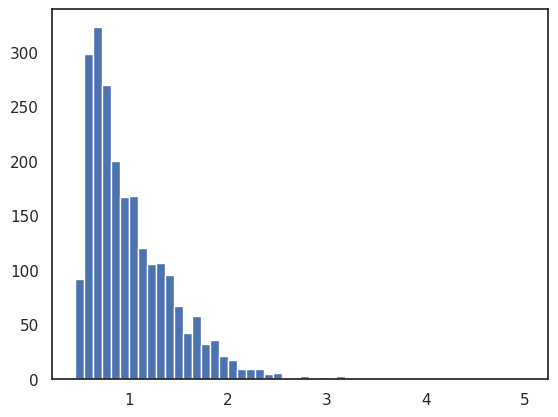

In [89]:
plt.hist(psi_data.global_PSI, bins=50)

In [11]:
# =========================================================
# 6) Can gene embeddings predict PSI? Ridge regression + classification
# =========================================================
from sklearn.linear_model import RidgeCV, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, roc_auc_score, accuracy_score
from scipy.stats import spearmanr
import pickle

# Load embedding sources
sys.path.insert(0, '/cwork/hl489/perturbBench/residual_datasets')
from embedding_ridge_xgb import load_embedding_source, EMB_SOURCES

# avg_psi already set from psi_data in cell above

# Also load GenePT v2 protein embeddings (best performer in emb_predict_perf2)
genept_v2_path = "/cwork/hl489/perturbBench/residual_datasets/embeddings/GenePT_emebdding_v2/GenePT_gene_protein_embedding_model_3_text.pickle"
with open(genept_v2_path, "rb") as f:
    genept_v2_dict = pickle.load(f)

avg_psi = psi_data.set_index('perturbation')['global_PSI']

emb_sources = {
    "genePT": "genePT",
    "genePT_v2_protein": genept_v2_dict,
    "geneformer": "geneformer",
    "scGPT": "scGPT",
    "GeOKG_200": "GeOKG_200",
    "GeOKG": "GeOKG",
    "GeOKG_1000": "GeOKG_1000"
}

def load_and_normalize(src):
    """Load embeddings and L2-normalize: g(p) / ||g(p)||_2"""
    if isinstance(src, dict):
        emb2idx = {g: i for i, g in enumerate(src.keys())}
        emb_array = np.array(list(src.values()), dtype=np.float32)
    else:
        emb_array, emb2idx = load_embedding_source(src)
    # L2 normalize each embedding vector
    emb_array = normalize(emb_array, norm='l2', axis=1)
    return emb_array, emb2idx

print(f"Perturbations with global PSI: {len(avg_psi)}")
print(f"Q25={q25:.4f}, Q75={q75:.4f}")
print(f"Hammers: {len(hammers)}, Scalpels: {len(scalpels)}")

NameError: name 'psi_data' is not defined

In [19]:
# # =========================================================
# # 6a) Ridge regression: predict ranked PSI from gene embeddings (5-fold CV)
# # =========================================================
# from scipy.stats import rankdata

# alphas = np.logspace(-2, 6, 30)
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# pc_grid = [10, 20, 50, 100, 200, 500]
# reg_results = []

# print(f"{'Source':>25s} | {'PCs':>3s} | {'n':>4s} | {'rho2':>8s} | {'R2_mean':>8s} | {'min':>6s} | {'max':>6s} | {'rho':>6s} | {'p-val':>10s}")
# print("-" * 100)

# for src_name, src in emb_sources.items():
#     emb_array, emb2idx = load_and_normalize(src)

#     perts_in = [p for p in avg_psi.index if p in emb2idx]
#     if len(perts_in) < 30:
#         print(f"{src_name:>25s} |     | {len(perts_in):>4d} | skipped (too few)")
#         continue

#     X_raw = np.array([emb_array[emb2idx[p]] for p in perts_in], dtype=np.float32)
#     # y = rankdata(avg_psi.loc[perts_in].values)
#     y = avg_psi.loc[perts_in].values.astype(float)

#     max_comp = X_raw.shape[1]

#     for n_comp in pc_grid:
#         if n_comp > max_comp:
#             continue

#         r2_scores, mae_scores = [], []
#         y_pred = np.empty(len(y))
#         for tr_idx, te_idx in kf.split(X_raw):
#             scaler = StandardScaler().fit(X_raw[tr_idx])
#             pca = PCA(n_components=n_comp, random_state=42).fit(scaler.transform(X_raw[tr_idx]))
#             X_tr = pca.transform(scaler.transform(X_raw[tr_idx]))
#             X_te = pca.transform(scaler.transform(X_raw[te_idx]))

#             m = RidgeCV(alphas=alphas).fit(X_tr, y[tr_idx])
#             preds = m.predict(X_te)
#             y_pred[te_idx] = preds
#             r2_scores.append(r2_score(y[te_idx], preds))
#             mae_scores.append(mean_absolute_error(y[te_idx], preds))

#         rho, pval = spearmanr(y, y_pred)
#         rho2 = rho ** 2

#         reg_results.append({
#             'source': src_name, 'n_pcs': n_comp,
#             'n': len(perts_in),
#             'rho2': rho2,
#             'r2_mean': np.mean(r2_scores), 'r2_min': np.min(r2_scores), 'r2_max': np.max(r2_scores),
#             'mae_mean': np.mean(mae_scores), 'mae_min': np.min(mae_scores), 'mae_max': np.max(mae_scores),
#             'rho': rho, 'pval': pval,
#         })

#         print(f"{src_name:>25s} | {n_comp:>3d} | {len(perts_in):>4d} | {rho2:>+8.4f} | {np.mean(r2_scores):>+8.4f} | {np.min(r2_scores):>+6.3f} | {np.max(r2_scores):>+6.3f} | {rho:>6.3f} | {pval:>10.2e}")

#     print()

# reg_results_df_unranked = pd.DataFrame(reg_results)


In [20]:
# # =========================================================
# # 6b) Classification: predict hammer/scalpel vs rest from gene embeddings
# # =========================================================
# # Scaler + PCA fit on train only (no look-ahead bias)
# # Sweep over different numbers of PCs
# from sklearn.metrics import average_precision_score
# from sklearn.model_selection import StratifiedKFold
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# pc_grid = [10, 20, 50, 100, 200, 500]
# clf_results = []

# for task_name, positive_set in [("HAMMER (bottom 25%) vs rest", hammers),
#                                  ("SCALPEL (top 25%) vs rest", scalpels)]:
#     print(f"\n{'='*105}")
#     print(f"  {task_name}")
#     print(f"{'='*105}")
#     print(f"{'Source':>25s} | {'PCs':>3s} | {'n':>4s} | {'n_pos':>5s} | {'AUROC':>7s} | {'min':>5s} | {'max':>5s} | {'AUPRC':>7s} | {'min':>5s} | {'max':>5s}")
#     print("-" * 105)

#     for src_name, src in emb_sources.items():
#         emb_array, emb2idx = load_and_normalize(src)

#         perts_in = [p for p in avg_psi.index if p in emb2idx]
#         if len(perts_in) < 30:
#             print(f"{src_name:>25s} |     | {len(perts_in):>4d} | skipped (too few)")
#             continue

#         X_raw = np.array([emb_array[emb2idx[p]] for p in perts_in], dtype=np.float32)
#         y = np.array([1 if p in positive_set else 0 for p in perts_in])
#         max_comp = X_raw.shape[1]

#         for n_comp in pc_grid:
#             if n_comp > max_comp:
#                 continue

#             auc_scores, auprc_scores = [], []
#             for tr_idx, te_idx in skf.split(X_raw, y):
#                 scaler = StandardScaler().fit(X_raw[tr_idx])
#                 pca = PCA(n_components=n_comp, random_state=42).fit(scaler.transform(X_raw[tr_idx]))
#                 X_tr = pca.transform(scaler.transform(X_raw[tr_idx]))
#                 X_te = pca.transform(scaler.transform(X_raw[te_idx]))

#                 m = LogisticRegressionCV(Cs=10, cv=5, penalty='l2', max_iter=5000,
#                                           random_state=42).fit(X_tr, y[tr_idx])
#                 probs = m.predict_proba(X_te)[:, 1]
#                 if len(np.unique(y[te_idx])) == 2:
#                     auc_scores.append(roc_auc_score(y[te_idx], probs))
#                     auprc_scores.append(average_precision_score(y[te_idx], probs))

#             auc_mean = np.mean(auc_scores) if auc_scores else float('nan')
#             auc_min = np.min(auc_scores) if auc_scores else float('nan')
#             auc_max = np.max(auc_scores) if auc_scores else float('nan')
#             auprc_mean = np.mean(auprc_scores) if auprc_scores else float('nan')
#             auprc_min = np.min(auprc_scores) if auprc_scores else float('nan')
#             auprc_max = np.max(auprc_scores) if auprc_scores else float('nan')
#             n_pos = y.sum()

#             clf_results.append({
#                 'task': task_name, 'source': src_name, 'n_pcs': n_comp,
#                 'n': len(perts_in), 'n_pos': n_pos,
#                 'auroc_mean': auc_mean, 'auroc_min': auc_min, 'auroc_max': auc_max,
#                 'auprc_mean': auprc_mean, 'auprc_min': auprc_min, 'auprc_max': auprc_max,
#             })

#             print(f"{src_name:>25s} | {n_comp:>3d} | {len(perts_in):>4d} | {n_pos:>5d} | {auc_mean:>7.4f} | {auc_min:>5.3f} | {auc_max:>5.3f} | {auprc_mean:>7.4f} | {auprc_min:>5.3f} | {auprc_max:>5.3f}")

#         print()  # blank line between embeddings

#     print(f"  (random baseline AUPRC = {len(positive_set)/len(avg_psi):.3f})")

# clf_results_df = pd.DataFrame(clf_results)


In [3]:
# clf_results_df.to_parquet("clf_results_df_large.parquet")
# reg_results_df_unranked.to_parquet("reg_results_df_large.parquet")
clf_results_df = pd.read_parquet("clf_results_df_large.parquet")
reg_results_df_unranked = pd.read_parquet("reg_results_df_large.parquet")


In [ ]:
reg_results_df_unranked

,source,n_pcs,n,rho2,r2_mean,r2_min,r2_max,mae_mean,mae_min,mae_max,rho,pval
0,genePT,10,2263,0.131415,0.112861,0.077785,0.138415,0.307209,0.298932,0.316366,0.362512,3.102523e-71
1,genePT,20,2263,0.141521,0.121528,0.092912,0.154723,0.306724,0.297108,0.315294,0.376193,5.365976e-77
2,genePT,50,2263,0.164693,0.142848,0.115180,0.172077,0.300976,0.291313,0.311976,0.405823,1.830995e-90
3,genePT,100,2263,0.169042,0.143667,0.125216,0.168898,0.300791,0.291375,0.312128,0.411147,4.944848e-93
4,genePT,200,2263,0.172752,0.145526,0.126505,0.169682,0.299975,0.291356,0.312222,0.415634,3.106622e-95
5,genePT,500,2263,0.175800,0.150212,0.132256,0.173640,0.299300,0.290682,0.311240,0.419285,4.745778e-97
6,genePT_v2_protein,10,2263,0.201925,0.167827,0.135726,0.207066,0.293867,0.282898,0.303410,0.449361,6.784840e-113
7,genePT_v2_protein,20,2263,0.212793,0.177551,0.151547,0.208744,0.291734,0.282626,0.303429,0.461295,1.226318e-119
8,genePT_v2_protein,50,2263,0.230987,0.190284,0.159465,0.227255,0.287240,0.278371,0.300882,0.480611,3.893573e-131
9,genePT_v2_protein,100,2263,0.239057,0.196315,0.162492,0.228563,0.285175,0.275630,0.298580,0.488935,2.531857e-136


In [12]:
save_plot = True

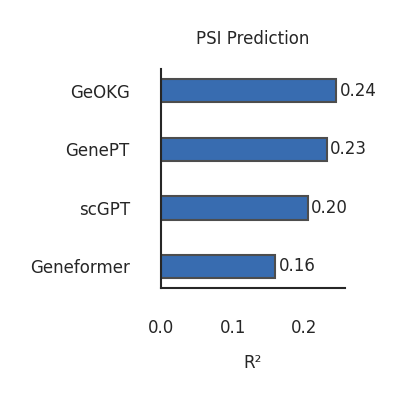

In [8]:
plot_sources = ['geneformer', 'scGPT', 'genePT_v2_protein', 'GeOKG']
source_labels = {'genePT_v2_protein': 'GenePT', 'geneformer': 'Geneformer', 'scGPT': 'scGPT', 'GeOKG': 'GeOKG'}



best_pc = 50

best_df = reg_results_df_unranked[(reg_results_df_unranked['source'].isin(plot_sources)) &
                                   (reg_results_df_unranked['n_pcs'] == best_pc)]

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(1.5, 1.5), dpi=300)

sub = best_df.set_index('source').loc[plot_sources]
y_pos = np.arange(len(plot_sources))
bar_h = 0.4

ax.barh(y_pos, sub['rho2'], height=bar_h, color='#386cb0',
        edgecolor='0.3', linewidth=0.5)

for i, src in enumerate(plot_sources):
    val = sub.loc[src, 'rho2']
    ax.text(val + 0.005, i, f'{val:.2f}', va='center', fontsize=4)

ax.set_yticks(y_pos)
ax.set_yticklabels([source_labels[s] for s in plot_sources], fontsize=4)
ax.set_xlabel('R²', fontsize=4)
ax.set_title('PSI Prediction', fontsize=4)
ax.tick_params(axis='x', labelsize=4, direction='out', length=4, width=0.8)
ax.tick_params(axis='y', labelsize=4, direction='out', length=4, width=0.8)

sns.despine(ax=ax, top=True, right=True)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

plt.tight_layout()
if save_plot:
    plt.savefig('Fig2/Fig2B_emb_regression_rho2.png', bbox_inches='tight', dpi=300)
    plt.savefig('Fig2/Fig2B_emb_regression_rho2.svg', bbox_inches='tight')
plt.show()


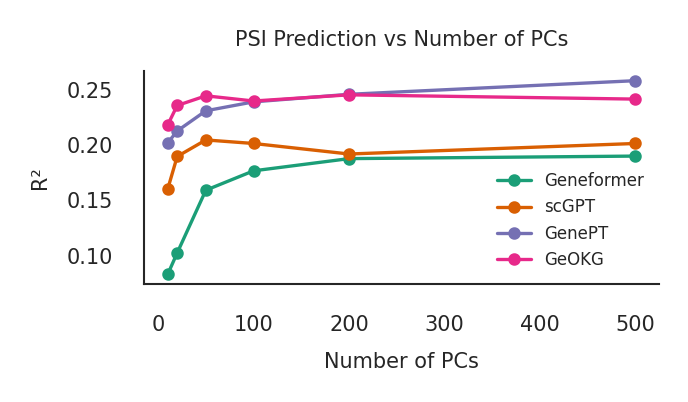

In [ ]:
plot_sources = ['geneformer', 'scGPT', 'genePT_v2_protein', 'GeOKG']
source_labels = {'genePT_v2_protein': 'GenePT', 'geneformer': 'Geneformer', 'scGPT': 'scGPT', 'GeOKG': 'GeOKG'}
source_colors = {'geneformer': '#1b9e77', 'scGPT': '#d95f02', 'genePT_v2_protein': '#7570b3', 'GeOKG': '#e7298a'}

sub = reg_results_df_unranked[reg_results_df_unranked['source'].isin(plot_sources)].copy()

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)

for src in plot_sources:
    src_data = sub[sub['source'] == src].sort_values('n_pcs')
    ax.plot(src_data['n_pcs'], src_data['rho2'], 
            color=source_colors[src], linewidth=0.8, marker='o', markersize=2,
            label=source_labels[src])

ax.set_xlabel('Number of PCs', fontsize=5)
ax.set_ylabel('R²', fontsize=5)
ax.set_title('PSI Prediction vs Number of PCs', fontsize=5)
ax.legend(fontsize=4, frameon=False)
ax.tick_params(labelsize=5, direction='out', length=4, width=0.8)
sns.despine(ax=ax)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
plt.tight_layout()
if save_plot:
    plt.savefig('FigSupp/FigSupp_emb_regression_pcs_sweep.png', bbox_inches='tight', dpi=300)
    plt.savefig('FigSupp/FigSupp_emb_regression_pcs_sweep.svg', bbox_inches='tight')
plt.show()


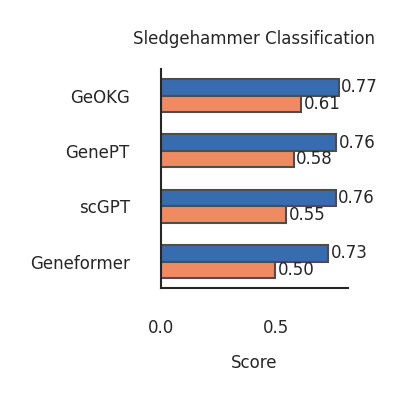

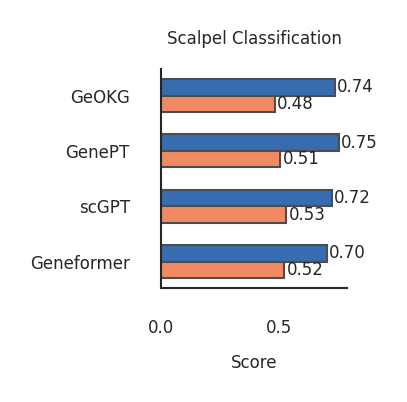

In [15]:
# =========================================================
# 6b plot) Classification performance: AUROC & AUPRC bar chart
# =========================================================
plot_sources = ['geneformer', 'scGPT', 'genePT_v2_protein', 'GeOKG']
source_labels = {'genePT_v2_protein': 'GenePT', 'geneformer': 'Geneformer', 'scGPT': 'scGPT', 'GeOKG': 'GeOKG'}

display_names = {'HAMMER (bottom 25%) vs rest': 'Sledgehammer Classification', 'SCALPEL (top 25%) vs rest': 'Scalpel Classification'}

best_pc = 50

best_df = clf_results_df[(clf_results_df['source'].isin(plot_sources)) &
                          (clf_results_df['n_pcs'] == best_pc)]

sns.set_theme(style="white")

for task_name in ["HAMMER (bottom 25%) vs rest", "SCALPEL (top 25%) vs rest"]:
    fig, ax = plt.subplots(figsize=(1.5, 1.5), dpi=300)

    sub = best_df[best_df['task'] == task_name].set_index('source').loc[plot_sources]
    y_pos = np.arange(len(plot_sources))
    bar_h = 0.3

    ax.barh(y_pos + bar_h/2, sub['auroc_mean'], height=bar_h, color='#386cb0',
            edgecolor='0.3', linewidth=0.5, label='AUROC')
    ax.barh(y_pos - bar_h/2, sub['auprc_mean'], height=bar_h, color='#ef8a62',
            edgecolor='0.3', linewidth=0.5, label='AUPRC')

    for i, src in enumerate(plot_sources):
        row = sub.loc[src]
        ax.text(row['auroc_mean'] + 0.01, i + bar_h/2, f'{row["auroc_mean"]:.2f}', va='center', fontsize=4)
        ax.text(row['auprc_mean'] + 0.01, i - bar_h/2, f'{row["auprc_mean"]:.2f}', va='center', fontsize=4)

    ax.set_yticks(y_pos)
    ax.set_yticklabels([source_labels[s] for s in plot_sources], fontsize=4)
    ax.set_xlabel('Score', fontsize=4)
    ax.set_title(display_names[task_name], fontsize=4)
    ax.tick_params(axis='x', labelsize=4, direction='out', length=4, width=0.8)
    ax.tick_params(axis='y', labelsize=4, direction='out', length=4, width=0.8)
    ax.legend(fontsize=4, loc='lower right', bbox_to_anchor=(1.1, 0.05), frameon=False)
    ax.legend_.remove()


    sns.despine(ax=ax, top=True, right=True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    plt.tight_layout()
    tag = 'sledgehammer' if 'HAMMER' in task_name else 'scalpel'
    if save_plot:
        plt.savefig(f'Fig2/Fig2B_emb_classification_{tag}.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'Fig2/Fig2B_emb_classification_{tag}.svg', bbox_inches='tight')
    plt.show()


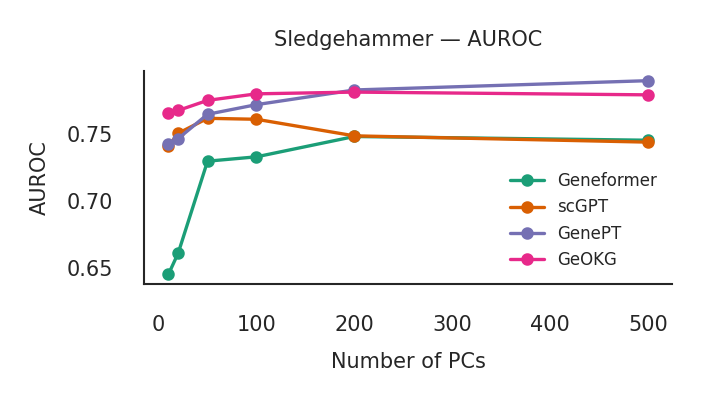

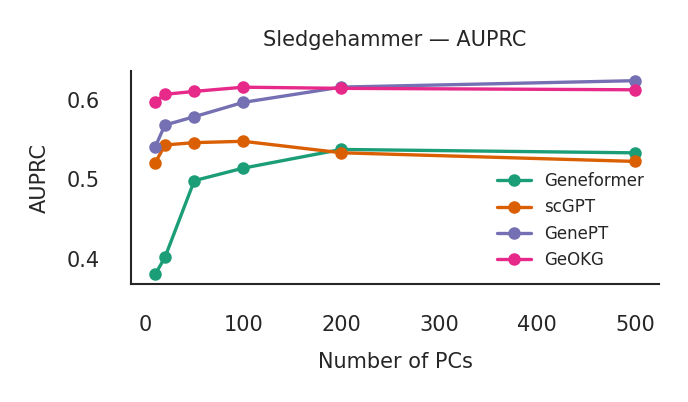

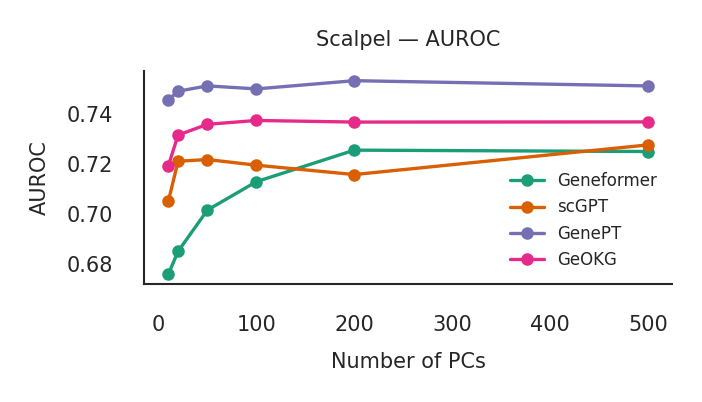

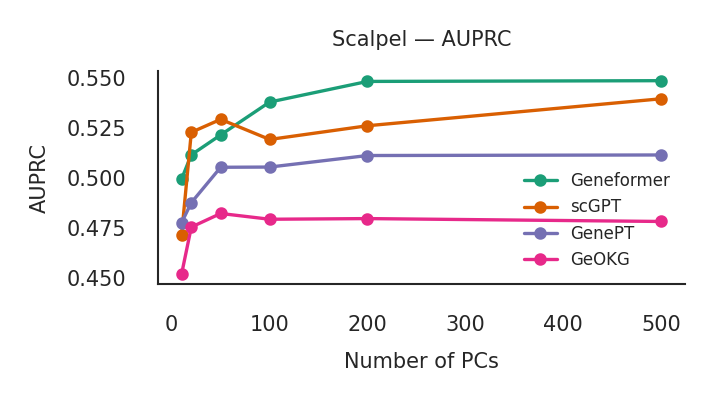

In [21]:
plot_sources = ['geneformer', 'scGPT', 'genePT_v2_protein', 'GeOKG']
source_labels = {'genePT_v2_protein': 'GenePT', 'geneformer': 'Geneformer', 'scGPT': 'scGPT', 'GeOKG': 'GeOKG'}
source_colors = {'geneformer': '#1b9e77', 'scGPT': '#d95f02', 'genePT_v2_protein': '#7570b3', 'GeOKG': '#e7298a'}

display_names = {'HAMMER (bottom 25%) vs rest': 'Sledgehammer', 'SCALPEL (top 25%) vs rest': 'Scalpel'}

sub = clf_results_df[clf_results_df['source'].isin(plot_sources)].copy()

sns.set_theme(style="white")

for task_name in ["HAMMER (bottom 25%) vs rest", "SCALPEL (top 25%) vs rest"]:
    task_data = sub[sub['task'] == task_name]
    tag = 'sledgehammer' if 'HAMMER' in task_name else 'scalpel'
    
    for metric, metric_label in [('auroc_mean', 'AUROC'), ('auprc_mean', 'AUPRC')]:
        fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)
        
        for src in plot_sources:
            src_data = task_data[task_data['source'] == src].sort_values('n_pcs')
            ax.plot(src_data['n_pcs'], src_data[metric],
                    color=source_colors[src], linewidth=0.8, marker='o', markersize=2,
                    label=source_labels[src])
        
        ax.set_xlabel('Number of PCs', fontsize=5)
        ax.set_ylabel(metric_label, fontsize=5)
        ax.set_title(f'{display_names[task_name]} — {metric_label}', fontsize=5)
        ax.legend(fontsize=4, frameon=False)
        ax.tick_params(labelsize=5, direction='out', length=4, width=0.8)
        sns.despine(ax=ax)
        ax.spines['left'].set_linewidth(0.5)
        ax.spines['bottom'].set_linewidth(0.5)
        
        plt.tight_layout()
        if save_plot:
            plt.savefig(f'FigSupp/FigSupp_emb_classification_{tag}_{metric}_pcs_sweep.png', bbox_inches='tight', dpi=300)
            plt.savefig(f'FigSupp/FigSupp_emb_classification_{tag}_{metric}_pcs_sweep.svg', bbox_inches='tight')
        plt.show()


In [26]:
# =========================================================
# 3) Mann-Whitney: continuous PSI vs GO term membership
# =========================================================
avg_psi = psi_data.set_index('perturbation')['global_PSI']

def go_psi_mw(avg_psi, go_df, min_genes=5):
    """Mann-Whitney: does GO term membership predict PSI?"""
    go_groups = go_df.groupby(["GO_ID", "GO_Name", "Ontology"])["DB_Object_Symbol"].apply(set)
    
    # Precompute once
    all_genes = set(avg_psi.index)
    psi_values = avg_psi.values
    gene_to_idx = {g: i for i, g in enumerate(avg_psi.index)}
    
    results = []
    for (go_id, go_name, ontology), genes in go_groups.items():
        genes_in = genes & all_genes
        if len(genes_in) < min_genes:
            continue
        
        idx_in = np.array([gene_to_idx[g] for g in genes_in])
        mask = np.zeros(len(psi_values), dtype=bool)
        mask[idx_in] = True
        
        psi_in = psi_values[mask]
        psi_out = psi_values[~mask]
        stat, pval = mannwhitneyu(psi_in, psi_out, alternative="two-sided")
        results.append({
            "GO_ID": go_id, "GO_Name": go_name, "Ontology": ontology,
            "n_genes": len(genes_in),
            "mean_PSI_in": psi_in.mean(), "mean_PSI_out": psi_out.mean(),
            "delta": psi_in.mean() - psi_out.mean(), "pval": pval,
        })
    res = pd.DataFrame(results).sort_values("pval")
    if len(res) == 0:
        return res
    res["pval_adj"] = np.nan
    for ont, idx in res.groupby("Ontology").groups.items():
        _, padj, _, _ = multipletests(res.loc[idx, "pval"], method="fdr_bh")
        res.loc[idx, "pval_adj"] = padj
    return res


print("Functions defined.")
mw_psi = go_psi_mw(avg_psi, go_filtered, min_genes=10)


Functions defined.


In [27]:
# # =========================================================
# # 4) Controlled OLS + F-test: PSI ~ GO_term + depth + level + n_terms
# # =========================================================
from scipy.stats import f as f_dist
from sklearn.linear_model import LinearRegression

def go_psi_controlled(avg_psi, go_df, min_genes=5):
    """OLS: does GO term membership predict PSI after controlling for depth/level/n_terms?"""
    gene_features = go_df.groupby("DB_Object_Symbol").agg(
        mean_depth=("depth", "mean"),
        mean_level=("level", "mean"),
        n_terms=("GO_ID", "count"),
    )
    gene_features = gene_features[gene_features.index.isin(avg_psi.index)]
    gene_features["psi"] = avg_psi.loc[gene_features.index].values

    go_groups = go_df.groupby(["GO_ID", "GO_Name", "Ontology"])["DB_Object_Symbol"].apply(set)

    results = []
    for (go_id, go_name, ontology), genes in go_groups.items():
        genes_in = genes & set(gene_features.index)
        if len(genes_in) < min_genes:
            continue

        gf = gene_features.copy()
        gf["has_term"] = gf.index.isin(genes_in).astype(int)

        X_full = gf[["has_term", "mean_depth", "mean_level", "n_terms"]].values
        X_null = gf[["mean_depth", "mean_level", "n_terms"]].values
        y = gf["psi"].values

        model_full = LinearRegression().fit(X_full, y)
        model_null = LinearRegression().fit(X_null, y)

        ss_res_full = ((y - model_full.predict(X_full)) ** 2).sum()
        ss_res_null = ((y - model_null.predict(X_null)) ** 2).sum()

        n = len(y)
        f_stat = (ss_res_null - ss_res_full) / (ss_res_full / (n - X_full.shape[1] - 1))
        pval = f_dist.sf(f_stat, 1, n - X_full.shape[1] - 1)

        coef = model_full.coef_[0]  # coefficient for has_term

        results.append({
            "GO_ID": go_id, "GO_Name": go_name, "Ontology": ontology,
            "n_genes": len(genes_in),
            "coef": coef,  # negative = lower PSI (hammer), positive = higher PSI (scalpel)
            "pval": pval,
        })

    res = pd.DataFrame(results).sort_values("pval")
    res["pval_adj"] = np.nan
    for ont, idx in res.groupby("Ontology").groups.items():
        _, padj, _, _ = multipletests(res.loc[idx, "pval"], method="fdr_bh")
        res.loc[idx, "pval_adj"] = padj
    return res

ctrl_psi = go_psi_controlled(avg_psi, go_filtered,min_genes=10)

In [37]:
# =========================================================
# 5) Summary: GO terms significant in BOTH MW and Controlled (p < 0.05)
# =========================================================

# Pre-compute GO term depth/level
go_term_stats = go_filtered.groupby("GO_ID").agg(
    mean_depth=("depth", "mean"),
    mean_level=("level", "mean"),
).to_dict("index")

# Build GO_ID -> list of perturbation genes (sorted by PSI)
go_gene_groups = go_filtered[go_filtered["DB_Object_Symbol"].isin(avg_psi.index)].groupby("GO_ID")["DB_Object_Symbol"].apply(
    lambda g: sorted(set(g), key=lambda x: avg_psi.get(x, 0))
).to_dict()

mw_indexed = mw_psi.set_index("GO_ID")
ctrl_indexed = ctrl_psi.set_index("GO_ID")

merged = mw_indexed[["GO_Name", "Ontology", "n_genes", "delta", "pval", "pval_adj"]].join(
    ctrl_indexed[["coef", "pval", "pval_adj"]], lsuffix="_mw", rsuffix="_ctrl", how="inner"
)

rows = []
for direction, label, sign_check in [
    ("HAMMERS", "delta < 0 & coef < 0", lambda r: r["delta"] < 0 and r["coef"] < 0),
    ("SCALPELS", "delta > 0 & coef > 0", lambda r: r["delta"] > 0 and r["coef"] > 0),
]:
    for ont in ["BP", "MF", "CC"]:
        ont_sub = merged[merged["Ontology"] == ont]
        sig = ont_sub[
            ((ont_sub["pval_adj_ctrl"] < 0.05) ) &
            ont_sub.apply(sign_check, axis=1)
        ]
        for gid, r in sig.iterrows():
            stats = go_term_stats.get(gid, {})
            genes = go_gene_groups.get(gid, [])
            rows.append({
                'direction': direction,
                'ontology': ont,
                'GO_ID': gid,
                'GO_Name': r['GO_Name'],
                'n_genes': r['n_genes'],
                'depth': stats.get('mean_depth', float('nan')),
                'level': stats.get('mean_level', float('nan')),
                'mw_delta': r['delta'],
                'mw_pval': r['pval_mw'],
                'mw_pval_adj': r['pval_adj_mw'],
                'ctrl_coef': r['coef'],
                'ctrl_pval': r['pval_ctrl'],
                'ctrl_pval_adj': r['pval_adj_ctrl'],
                'genes': ', '.join(genes),
            })

go_summary_df = pd.DataFrame(rows)
# go_summary_df


In [61]:
go_summary_df.to_csv("go_summary.csv")

In [31]:
# go_summary_df
pd.set_option('display.max_rows', 150)

In [38]:
go_summary_df[['direction', 'ontology', 'GO_Name']]

,direction,ontology,GO_Name
0,HAMMERS,BP,rRNA processing
1,HAMMERS,BP,ribosome biogenesis
2,HAMMERS,BP,ribosomal small subunit biogenesis
3,HAMMERS,BP,cytoplasmic translation
4,HAMMERS,BP,maturation of SSU-rRNA
5,HAMMERS,BP,negative regulation of myoblast fusion
6,HAMMERS,BP,striated muscle contraction
7,HAMMERS,BP,ribosomal large subunit biogenesis
8,HAMMERS,BP,RNA processing
9,HAMMERS,BP,maturation of SSU-rRNA from tricistronic rRNA ...


In [83]:
scalpels

{'AAAS',
 'AARS2',
 'ABCG1',
 'ABHD11',
 'ABHD17A',
 'ACIN1',
 'ACOT12',
 'ACTR1A',
 'ACTR1B',
 'ADAT2',
 'ADAT3',
 'ADRM1',
 'ADSL',
 'AHCY',
 'AIFM1',
 'ALG14',
 'ANAPC15',
 'ANKRD11',
 'ANKRD49',
 'ANKS6',
 'AP2M1',
 'AQP7',
 'ARGFX',
 'ARHGAP11B',
 'ARID3A',
 'ARID5B',
 'ARL4D',
 'ARMC6',
 'ARPC3',
 'ASF1B',
 'ATP1A1',
 'ATP6V1D',
 'BCAR1',
 'BCL2L1',
 'BCR',
 'BCS1L',
 'BOD1L1',
 'BRD2',
 'BRD4',
 'BRIP1',
 'BTF3L4',
 'C16orf86',
 'C17orf58',
 'C1QTNF4',
 'C6orf15',
 'C7orf50',
 'C9orf78',
 'CA5A',
 'CABIN1',
 'CACNB3',
 'CADM4',
 'CAP1',
 'CBFA2T3',
 'CBLL1',
 'CBLN1',
 'CBX1',
 'CCAR1',
 'CCDC144A',
 'CCDC144NL',
 'CCDC6',
 'CCDC78',
 'CCNB1',
 'CCND1',
 'CCND3',
 'CCNK',
 'CCP110',
 'CD8B',
 'CDIPT',
 'CDK11A',
 'CDK2',
 'CDK6',
 'CENPA',
 'CEP68',
 'CEP97',
 'CFDP1',
 'CHCHD1',
 'CHCHD2',
 'CHORDC1',
 'CHTOP',
 'CIAO1',
 'CKAP5',
 'CLASRP',
 'CLCC1',
 'CLK2',
 'CLPB',
 'CMPK1',
 'CNIH4',
 'CNN2',
 'CNOT10',
 'CNOT11',
 'COMTD1',
 'COPG1',
 'COPZ1',
 'COQ2',
 'COQ5',
 'COX10',
